# Importing Libraries

In [3]:
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Data Preprocessing

### Training Image Preprocessing

In [4]:
training_set = tf.keras.utils.image_dataset_from_directory(
    'train',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
)

Found 70295 files belonging to 38 classes.


### Validation Image Preprocessing

In [5]:
validation_set = tf.keras.utils.image_dataset_from_directory(
    'valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
)

Found 17572 files belonging to 38 classes.


In [6]:
training_set

<BatchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 38), dtype=tf.float32, name=None))>

In [7]:
for x,y in training_set:
    print(x,x.shape)
    print(y,y.shape)
    break

tf.Tensor(
[[[[175.5  164.5  168.5 ]
   [174.25 163.25 167.25]
   [166.25 155.25 159.25]
   ...
   [152.25 140.25 144.25]
   [152.5  140.5  144.5 ]
   [142.75 130.75 134.75]]

  [[166.75 155.75 159.75]
   [168.   157.   161.  ]
   [155.75 144.75 148.75]
   ...
   [154.75 142.75 146.75]
   [145.75 133.75 137.75]
   [143.25 131.25 135.25]]

  [[158.   147.   151.  ]
   [166.75 155.75 159.75]
   [166.5  155.5  159.5 ]
   ...
   [157.   145.   149.  ]
   [149.25 137.25 141.25]
   [141.   129.   133.  ]]

  ...

  [[170.5  159.5  163.5 ]
   [168.   157.   161.  ]
   [169.75 158.75 162.75]
   ...
   [151.25 139.25 139.25]
   [150.25 138.25 138.25]
   [150.75 138.75 138.75]]

  [[170.5  159.5  163.5 ]
   [165.5  154.5  158.5 ]
   [166.5  155.5  159.5 ]
   ...
   [154.5  142.5  142.5 ]
   [152.25 140.25 140.25]
   [152.5  140.5  140.5 ]]

  [[165.5  154.5  158.5 ]
   [164.75 153.75 157.75]
   [168.75 157.75 161.75]
   ...
   [159.   147.   147.  ]
   [156.5  144.5  144.5 ]
   [152.75 140.75 14

## Building Model 

In [26]:
from tensorflow.keras.layers import Dense,Conv2D,MaxPool2D,Flatten,Dropout
from tensorflow.keras.models import Sequential

In [35]:
model = Sequential()

## Convulation Layer

In [36]:
model.add(Conv2D(filters=32,kernel_size=3,padding='same',activation='relu',input_shape=[128,128,3]))
model.add(Conv2D(filters=32,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [37]:
model.add(Conv2D(filters=64,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=64,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [38]:
model.add(Conv2D(filters=128,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=128,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [39]:
model.add(Conv2D(filters=256,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=256,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [40]:
model.add(Conv2D(filters=512,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=512,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [41]:
model.add(Dropout(0.25)) #To Avoid Overfitting

In [42]:
model.add(Flatten())

In [43]:
model.add(Dense(units=1500,activation='relu'))

In [44]:
model.add(Dropout(0.4))

In [45]:
#Output Layer
model.add(Dense(units=38,activation='softmax'))

### Compiling Model 

In [46]:
model.compile(optimizer=tf.keras.optimizers.Adam(
    learning_rate=0.0001),loss='categorical_crossentropy',metrics=['accuracy'])

In [47]:
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_22 (Conv2D)          (None, 128, 128, 32)      896       
                                                                 
 conv2d_23 (Conv2D)          (None, 126, 126, 32)      9248      
                                                                 
 max_pooling2d_9 (MaxPooling  (None, 63, 63, 32)       0         
 2D)                                                             
                                                                 
 conv2d_24 (Conv2D)          (None, 63, 63, 64)        18496     
                                                                 
 conv2d_25 (Conv2D)          (None, 61, 61, 64)        36928     
                                                                 
 max_pooling2d_10 (MaxPoolin  (None, 30, 30, 64)       0         
 g2D)                                                 

### Model Training

In [48]:
train_history = model.fit(x=training_set,validation_data=validation_set,epochs=10)

Epoch 1/10
2197/2197 [==============================] - 165s 73ms/step - loss: 1.4399 - accuracy: 0.5794 - val_loss: 0.5941 - val_accuracy: 0.8146
Epoch 2/10
2197/2197 [==============================] - 157s 71ms/step - loss: 0.4618 - accuracy: 0.8536 - val_loss: 0.3178 - val_accuracy: 0.8984
Epoch 3/10
2197/2197 [==============================] - 160s 73ms/step - loss: 0.2774 - accuracy: 0.9098 - val_loss: 0.2564 - val_accuracy: 0.9180
Epoch 4/10
2197/2197 [==============================] - 157s 71ms/step - loss: 0.1873 - accuracy: 0.9400 - val_loss: 0.1683 - val_accuracy: 0.9445
Epoch 5/10
2197/2197 [==============================] - 160s 73ms/step - loss: 0.1395 - accuracy: 0.9537 - val_loss: 0.1893 - val_accuracy: 0.9396
Epoch 6/10
2197/2197 [==============================] - 159s 72ms/step - loss: 0.1139 - accuracy: 0.9618 - val_loss: 0.1257 - val_accuracy: 0.9610
Epoch 7/10
2197/2197 [==============================] - 158s 72ms/step - loss: 0.0910 - accuracy: 0.9704 - val_loss: 0

## Model Evaluation

In [ ]:
# Model Evaluation on Training Set
train_loss,train_acc=model.evaluate(training_set)

2197/2197 [==============================] - 68s 31ms/step - loss: 0.0228 - accuracy: 0.9930


In [55]:
print(train_loss,train_acc)

0.022846737876534462 0.9929582476615906


In [ ]:
# Model on Validation Set
val_loss,val_acc=model.evaluate(validation_set)

550/550 [==============================] - 19s 34ms/step - loss: 0.1095 - accuracy: 0.9661


In [58]:
print(val_loss,val_acc)

0.10945654660463333 0.9661393165588379


## Savng Model

In [60]:
model.save("training_model.keras")

In [74]:
train_history.history

{'loss': [1.4399349689483643,
  0.46184787154197693,
  0.2774337828159332,
  0.18731242418289185,
  0.13946540653705597,
  0.11390433460474014,
  0.09095313400030136,
  0.07577373087406158,
  0.06575652211904526,
  0.05714454874396324],
 'accuracy': [0.579429566860199,
  0.8536453247070312,
  0.9097802042961121,
  0.9400383830070496,
  0.9536666870117188,
  0.9618038535118103,
  0.9703677296638489,
  0.975261390209198,
  0.9780212044715881,
  0.9813642501831055],
 'val_loss': [0.594092607498169,
  0.31778961420059204,
  0.2564225196838379,
  0.16827283799648285,
  0.18927721679210663,
  0.12570902705192566,
  0.20203745365142822,
  0.12660379707813263,
  0.14155630767345428,
  0.10945648699998856],
 'val_accuracy': [0.8146483302116394,
  0.8984179496765137,
  0.9179945588111877,
  0.9445139765739441,
  0.9395629167556763,
  0.9610175490379333,
  0.9366605877876282,
  0.9611313343048096,
  0.9574891924858093,
  0.9661393165588379]}

In [63]:
# Recording history in json 
import json 
with open("training_hist.json","w") as f:
    json.dump(train_history.history,f)

## Accuracy Visualization

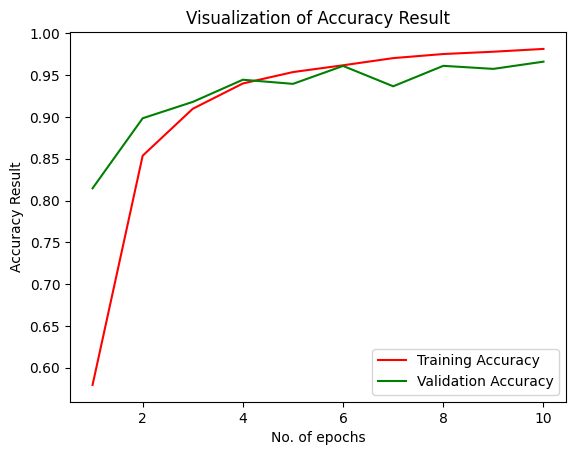

In [103]:
epochs = [i for i in range(1,11)]
plt.plot(epochs,train_history.history['accuracy'],color='red',label='Training Accuracy')
plt.plot(epochs,train_history.history['val_accuracy'],color='green',label='Validation Accuracy')
plt.xlabel("No. of epochs")
plt.ylabel("Accuracy Result")
plt.title("Visualization of Accuracy Result")
plt.legend()
plt.show()

In [65]:
train_history.history['accuracy']

[0.579429566860199,
 0.8536453247070312,
 0.9097802042961121,
 0.9400383830070496,
 0.9536666870117188,
 0.9618038535118103,
 0.9703677296638489,
 0.975261390209198,
 0.9780212044715881,
 0.9813642501831055]

### Some other metrics for model evaluation

In [73]:
class_name = validation_set.class_names
class_name

['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Blueberry___healthy',
 'Cherry_(including_sour)___Powdery_mildew',
 'Cherry_(including_sour)___healthy',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_

In [75]:
test_set=tf.keras.utils.image_dataset_from_directory(
    'valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=False,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
)

Found 17572 files belonging to 38 classes.


In [77]:
y_pred = model.predict(test_set)
y_pred,y_pred.shape

550/550 [==============================] - 13s 23ms/step


(array([[9.9897766e-01, 1.0008560e-03, 1.5360602e-09, ..., 2.6481625e-13,
         1.0859567e-12, 3.9006631e-11],
        [7.8988111e-01, 2.0989612e-01, 3.9704742e-06, ..., 1.8674384e-09,
         4.9792090e-09, 3.5782673e-08],
        [9.9998617e-01, 7.7311149e-08, 4.0277053e-09, ..., 1.3382110e-15,
         2.2308613e-13, 4.1324662e-11],
        ...,
        [7.0817516e-09, 4.9105855e-11, 2.6824408e-08, ..., 3.5332841e-09,
         9.2080690e-11, 9.9999487e-01],
        [4.1819781e-08, 1.3681904e-10, 8.3139852e-08, ..., 3.8447055e-08,
         4.0527978e-10, 9.9999082e-01],
        [5.2122490e-17, 4.4636308e-18, 1.4062294e-15, ..., 1.4929470e-17,
         2.5309448e-15, 1.0000000e+00]], dtype=float32),
 (17572, 38))

In [83]:
predicted_categories = tf.argmax(y_pred,axis=1)
predicted_categories

<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37], dtype=int64)>

In [84]:
true_categories = tf.concat([y for x,y in test_set],axis=0)
true_categories

<tf.Tensor: shape=(17572, 38), dtype=float32, numpy=
array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]], dtype=float32)>

In [87]:
Y_true = tf.argmax(true_categories,axis=1)
Y_true

<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37], dtype=int64)>

In [90]:
from sklearn.metrics import classification_report,confusion_matrix

In [89]:
print(classification_report(Y_true,predicted_categories,target_names=class_name))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.96      0.94      0.95       504
                                 Apple___Black_rot       0.96      0.99      0.98       497
                          Apple___Cedar_apple_rust       0.98      0.98      0.98       440
                                   Apple___healthy       0.98      0.90      0.94       502
                               Blueberry___healthy       0.98      0.98      0.98       454
          Cherry_(including_sour)___Powdery_mildew       0.99      0.99      0.99       421
                 Cherry_(including_sour)___healthy       0.99      0.98      0.98       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.90      0.95      0.92       410
                       Corn_(maize)___Common_rust_       1.00      0.99      0.99       477
               Corn_(maize)___Northern_Leaf_Blight       0.97      0.92      0.

In [92]:
cm = confusion_matrix(Y_true,predicted_categories)
cm.shape

(38, 38)

### Confusion Matrix Visualization

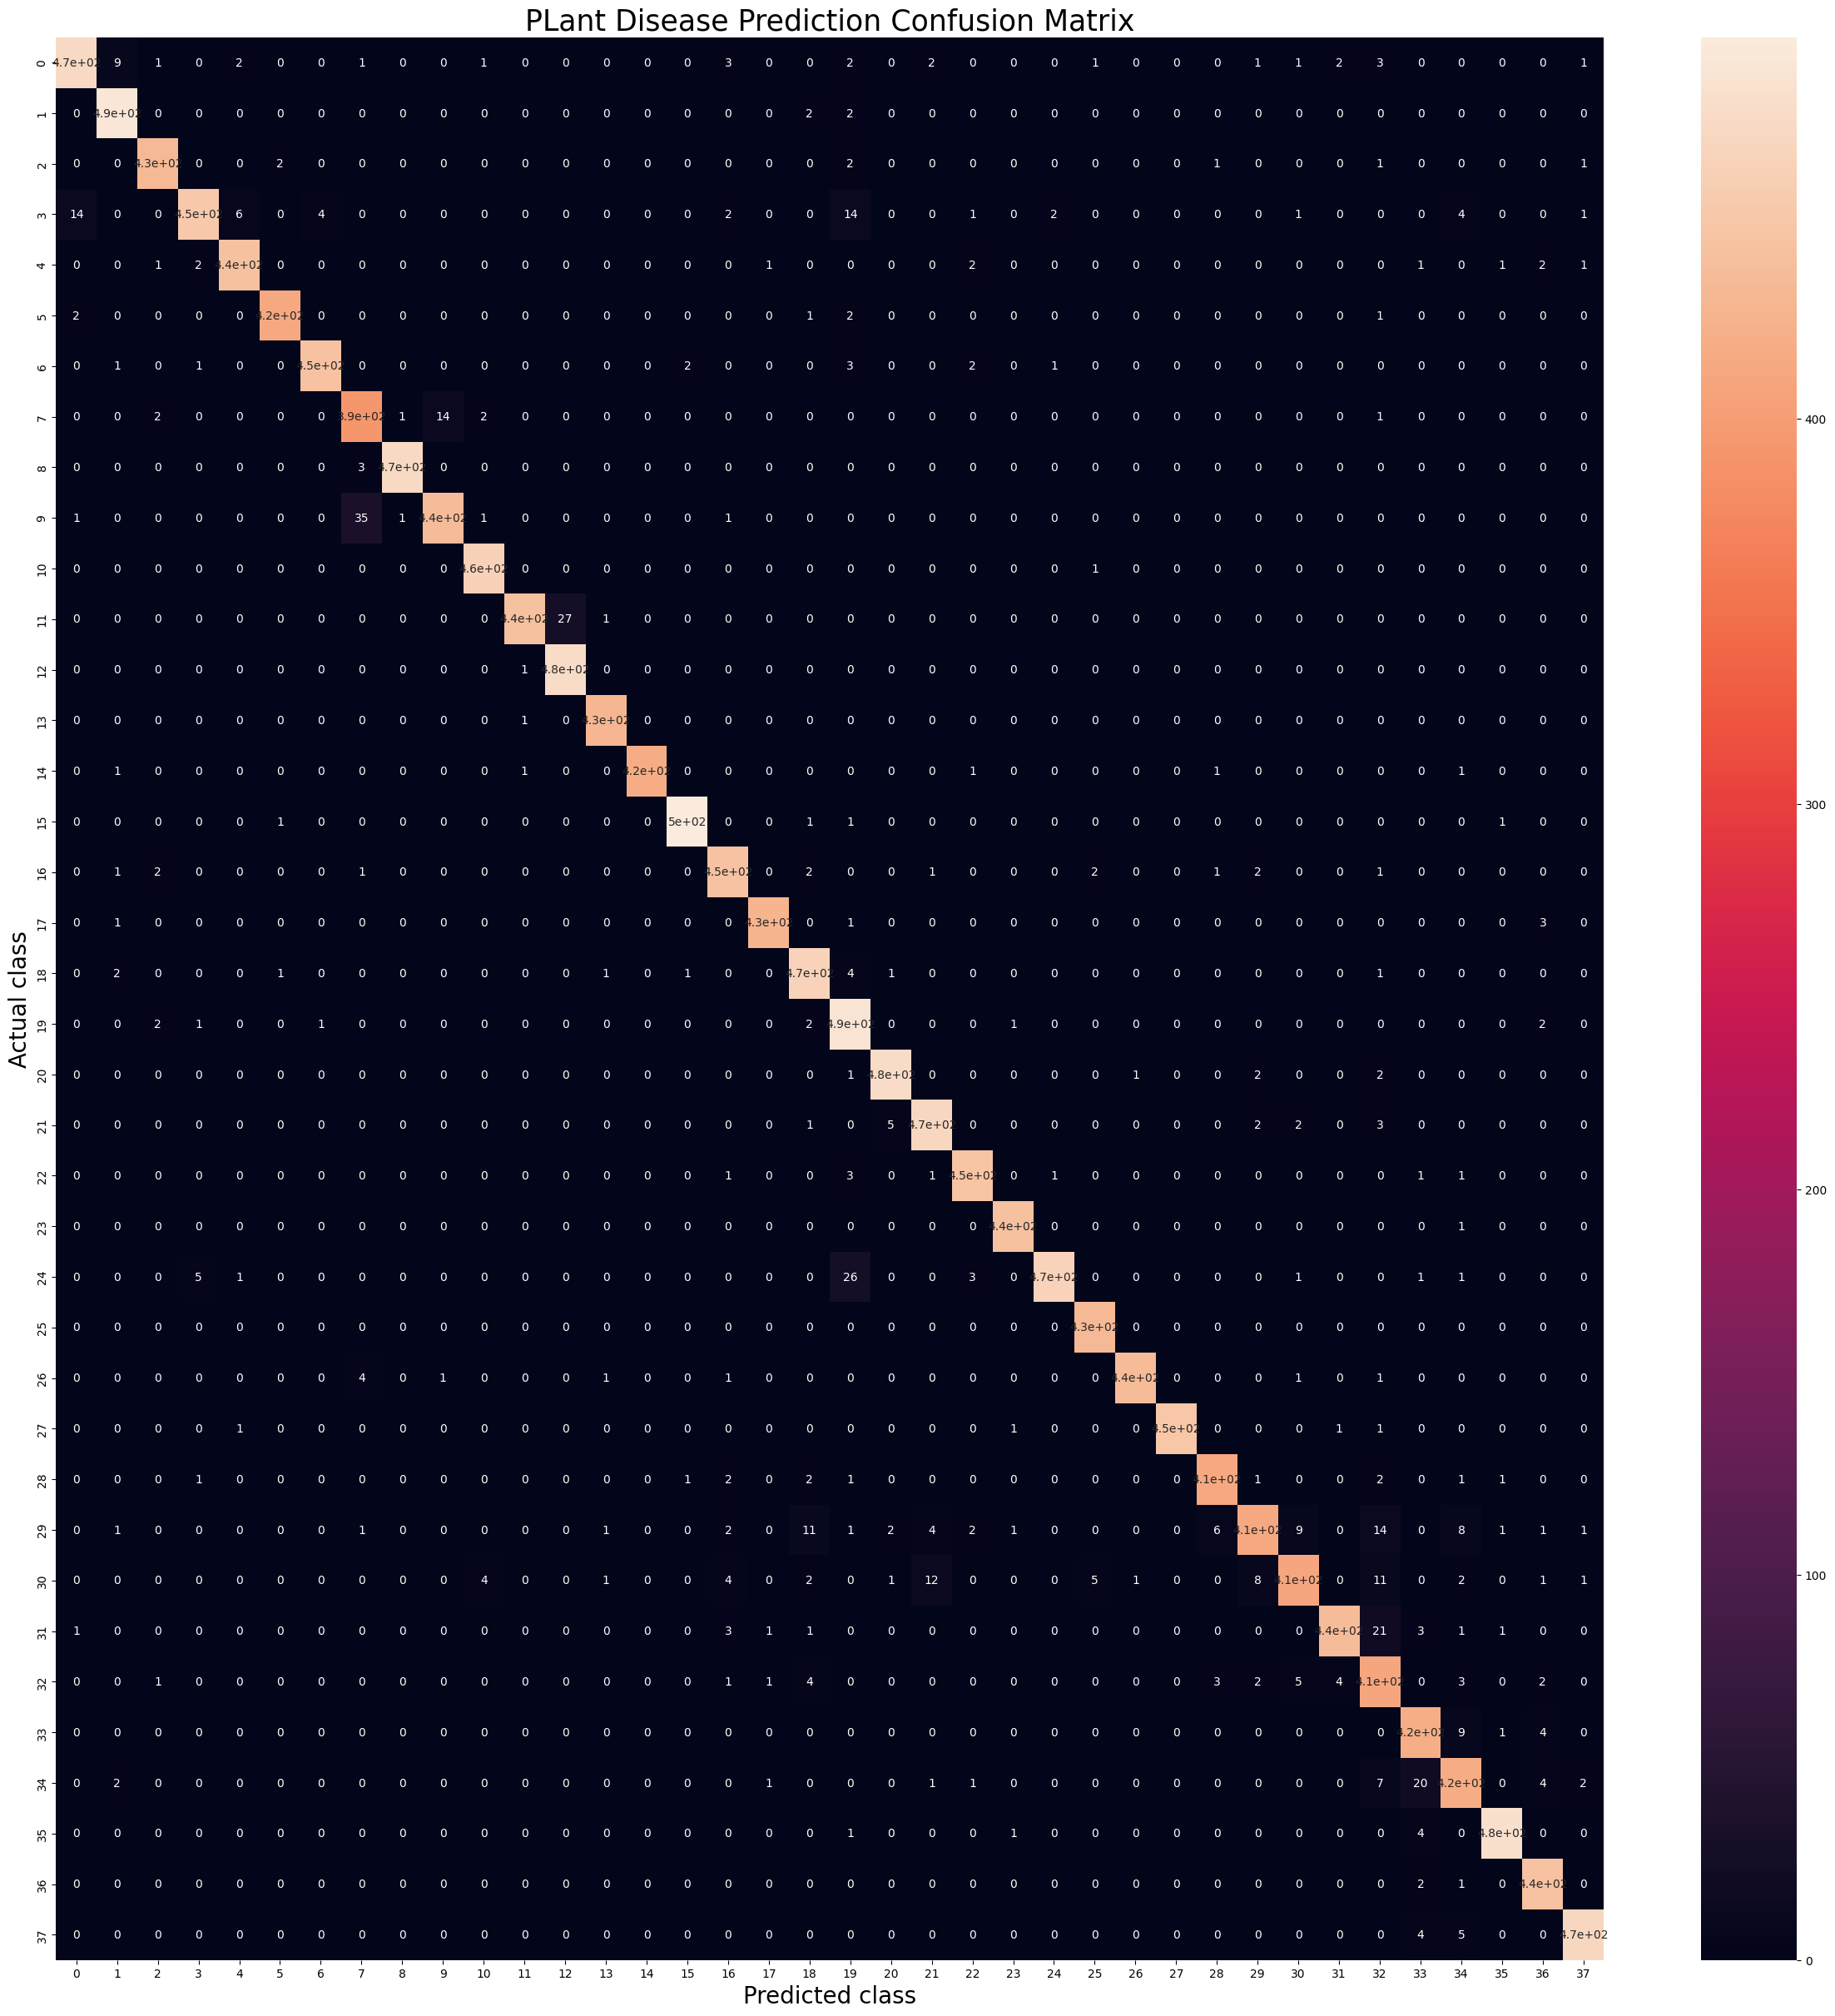

In [102]:
plt.figure(figsize=(30,30))
sns.heatmap(cm,annot=True,annot_kws={'size':10})
plt.xlabel("Predicted class",fontsize=20)
plt.ylabel("Actual class",fontsize=20)
plt.title("PLant Disease Prediction Confusion Matrix",fontsize=25)
plt.show()